# CCS/00020/022
# CCS/00117/022

In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.metrics import silhouette_score
from sklearn.model_selection import cross_val_score
from sklearn.datasets import load_iris

### Load and prepare data

In [16]:
# Load the Iris dataset
iris = load_iris()
data = pd.DataFrame(iris.data, columns=iris.feature_names)

X = data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

### Performing PCA

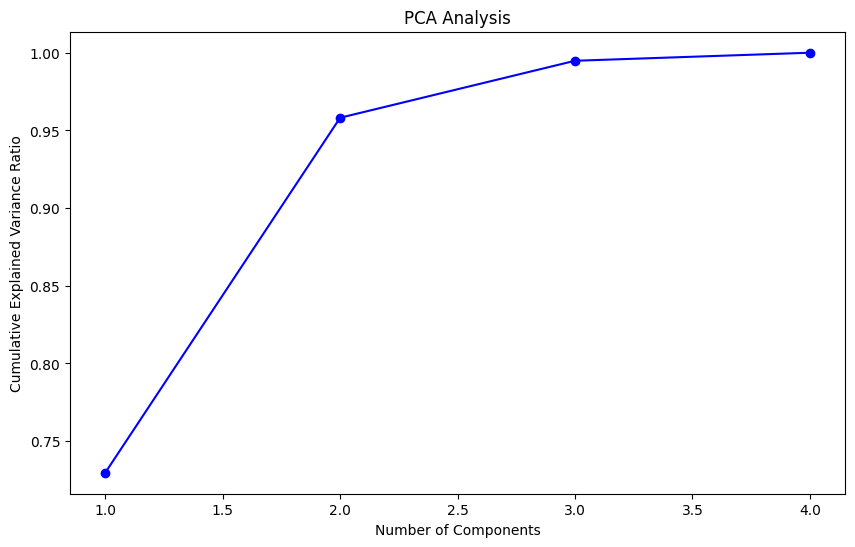

In [17]:
# PCA Analysis
pca = PCA()
X_pca = pca.fit_transform(X_scaled)

# Explained variance ratio
explained_variance = pca.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)

# Plot explained variance
plt.figure(figsize=(10, 6))
plt.plot(range(1, len(explained_variance) + 1), cumulative_variance, 'bo-')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance Ratio')
plt.title('PCA Analysis')
plt.show()


### 1.K-means (Partitional)

In [18]:
# K-means clustering
kmeans = KMeans(n_clusters=3, random_state=42)
kmeans_labels = kmeans.fit_predict(X_pca)

# Silhouette score for K-means
kmeans_silhouette = silhouette_score(X_pca, kmeans_labels)
print(f"K-means Silhouette Score: {kmeans_silhouette}")


K-means Silhouette Score: 0.4798814508199818


### 2.Hierarchical (Agglomerative)

In [19]:
# Hierarchical clustering
hierarchical = AgglomerativeClustering(n_clusters=3)
hierarchical_labels = hierarchical.fit_predict(X_pca)

# Silhouette score for Hierarchical
hierarchical_silhouette = silhouette_score(X_pca, hierarchical_labels)
print(f"Hierarchical Silhouette Score: {hierarchical_silhouette}")


Hierarchical Silhouette Score: 0.4466890410285909


### 3.Density-based (DBSCAN)

In [20]:
# DBSCAN clustering
dbscan = DBSCAN(eps=0.5, min_samples=5)
dbscan_labels = dbscan.fit_predict(X_pca)

# Silhouette score for DBSCAN (only if more than one cluster is found)
if len(np.unique(dbscan_labels)) > 1:
    dbscan_silhouette = silhouette_score(X_pca, dbscan_labels)
    print(f"DBSCAN Silhouette Score: {dbscan_silhouette}")


DBSCAN Silhouette Score: 0.3565164814270073


#### Visualization of clusters

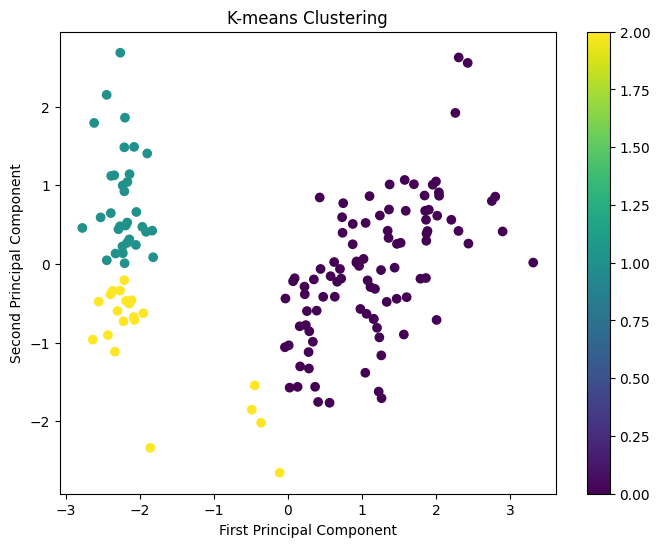

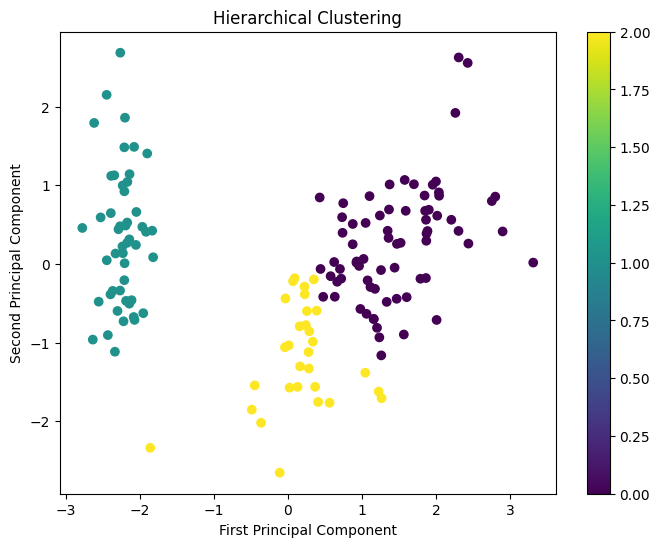

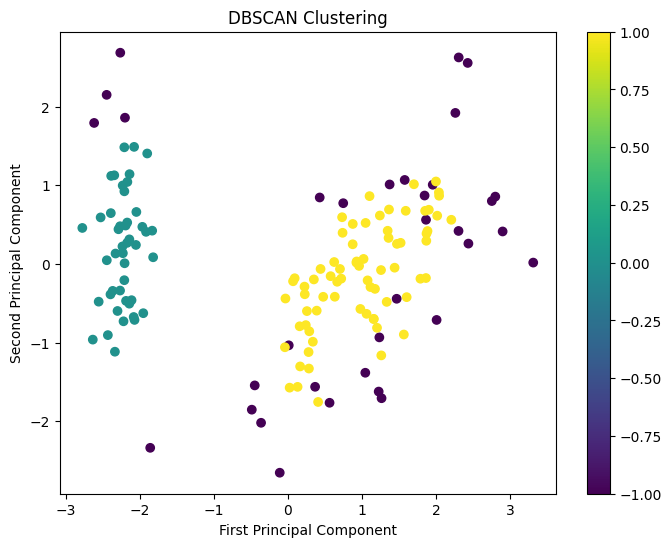

In [21]:
# Function to plot clusters
def plot_clusters(X_pca, labels, title):
    plt.figure(figsize=(8, 6))
    plt.scatter(X_pca[:, 0], X_pca[:, 1], c=labels, cmap='viridis')
    plt.title(title)
    plt.xlabel('First Principal Component')
    plt.ylabel('Second Principal Component')
    plt.colorbar()
    plt.show()

# Plot all clustering results
plot_clusters(X_pca, kmeans_labels, 'K-means Clustering')
plot_clusters(X_pca, hierarchical_labels, 'Hierarchical Clustering')
plot_clusters(X_pca, dbscan_labels, 'DBSCAN Clustering')


#### Cross-validation

In [22]:
from sklearn.metrics import make_scorer
from sklearn.model_selection import KFold

# Define a custom scoring function for clustering
def clustering_score(estimator, X):
    labels = estimator.fit_predict(X)
    return silhouette_score(X, labels)

# Create KFold cross-validator
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# Cross-validation for K-means
kmeans_scores = []
hierarchical_scores = []
dbscan_scores = []

for train_index, test_index in kf.split(X_pca):
    # K-means
    kmeans = KMeans(n_clusters=3, random_state=42)
    kmeans_labels = kmeans.fit_predict(X_pca[train_index])
    kmeans_scores.append(silhouette_score(X_pca[train_index], kmeans_labels))
    
    # Hierarchical
    hierarchical = AgglomerativeClustering(n_clusters=3)
    hierarchical_labels = hierarchical.fit_predict(X_pca[train_index])
    hierarchical_scores.append(silhouette_score(X_pca[train_index], hierarchical_labels))
    
    # DBSCAN
    dbscan = DBSCAN(eps=0.5, min_samples=5)
    dbscan_labels = dbscan.fit_predict(X_pca[train_index])
    if len(np.unique(dbscan_labels)) > 1:  # Check if DBSCAN found more than one cluster
        dbscan_scores.append(silhouette_score(X_pca[train_index], dbscan_labels))

print("K-means CV scores:", np.mean(kmeans_scores))
print("Hierarchical CV scores:", np.mean(hierarchical_scores))
print("DBSCAN CV scores:", np.mean(dbscan_scores))


K-means CV scores: 0.46287354308260076
Hierarchical CV scores: 0.45261968806829156
DBSCAN CV scores: 0.23030466470697558


#### Training The Model

In [23]:
# Split data into train and test sets
from sklearn.model_selection import train_test_split

X_train, X_test = train_test_split(X_pca, test_size=0.2, random_state=42)

# Train K-means model
kmeans_model = KMeans(n_clusters=3, random_state=42)
kmeans_model.fit(X_train)
kmeans_train_labels = kmeans_model.labels_
kmeans_test_labels = kmeans_model.predict(X_test)

# Train Hierarchical model
hierarchical_model = AgglomerativeClustering(n_clusters=3)
hierarchical_model.fit(X_train)
hierarchical_train_labels = hierarchical_model.labels_

# Train DBSCAN model
dbscan_model = DBSCAN(eps=0.5, min_samples=5)
dbscan_model.fit(X_train)
dbscan_train_labels = dbscan_model.labels_

# Evaluate models using silhouette scores
train_silhouette_kmeans = silhouette_score(X_train, kmeans_train_labels)
test_silhouette_kmeans = silhouette_score(X_test, kmeans_test_labels)

print("K-means Clustering Performance:")
print(f"Training Silhouette Score: {train_silhouette_kmeans:.3f}")
print(f"Testing Silhouette Score: {test_silhouette_kmeans:.3f}")


K-means Clustering Performance:
Training Silhouette Score: 0.453
Testing Silhouette Score: 0.458


#### Visualize the training results

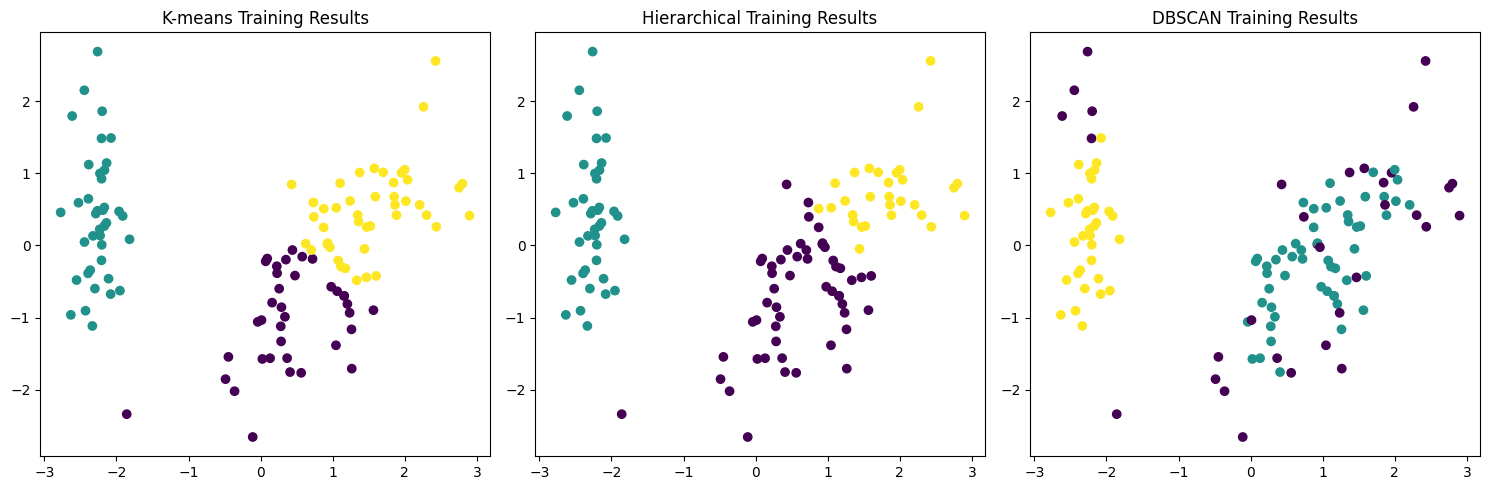

In [24]:
# Visualize training results
plt.figure(figsize=(15, 5))

# K-means results
plt.subplot(131)
plt.scatter(X_train[:, 0], X_train[:, 1], c=kmeans_train_labels, cmap='viridis')
plt.title('K-means Training Results')

# Hierarchical results
plt.subplot(132)
plt.scatter(X_train[:, 0], X_train[:, 1], c=hierarchical_train_labels, cmap='viridis')
plt.title('Hierarchical Training Results')

# DBSCAN results
plt.subplot(133)
plt.scatter(X_train[:, 0], X_train[:, 1], c=dbscan_train_labels, cmap='viridis')
plt.title('DBSCAN Training Results')

plt.tight_layout()
plt.show()
